<a href="https://colab.research.google.com/github/SydAt1/Eye_Disease_Classification/blob/main/notebooks/RandomForestClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, balanced_accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
# LOAD DATA
df = pd.read_csv("prepped_NHIS_dataset.csv")

print("Dataset shape:", df.shape)
print("\nRisk Level Distribution:")
print(df["Risk_Level"].value_counts(normalize=True).round(3))

Dataset shape: (11295, 10)

Risk Level Distribution:
Risk_Level
0    0.500
1    0.253
2    0.168
3    0.079
Name: proportion, dtype: float64


In [3]:
df['Age_range'].unique()

array([2, 3, 1, 6, 5, 4, 0])

In [36]:
df.drop(columns=["Unnamed: 0"], inplace=True)

In [5]:
feature_cols = [c for c in df.columns if c not in ["Data_Value", "Risk_Level", "Age"]]

X = df[feature_cols]
y = df["Risk_Level"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


In [6]:
# Trainig Random Forest Classifier

rf_clf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,          # let trees grow, forest will regularize
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [7]:
# PREDICTIONS
y_train_pred = rf_clf.predict(X_train)
y_test_pred = rf_clf.predict(X_test)


### Model Evaluation

In [8]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
balanced_acc = balanced_accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy:       {train_acc:.4f}")
print(f"Test Accuracy:           {test_acc:.4f}")
print(f"Balanced Test Accuracy:  {balanced_acc:.4f}\n")

print("Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

Training Accuracy:       0.8373
Test Accuracy:           0.6843
Balanced Test Accuracy:  0.6080

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.83      0.74      0.78      1693
           1       0.73      0.72      0.72       857
           2       0.64      0.64      0.64       570
           3       0.19      0.33      0.24       269

    accuracy                           0.68      3389
   macro avg       0.60      0.61      0.60      3389
weighted avg       0.72      0.68      0.70      3389



In [9]:
# Feature Importance
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_clf.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance_df.head(20).to_string(index=False))


             Feature  Importance
            Question    0.594074
           Age_range    0.135503
       RaceEthnicity    0.110472
RiskFactorResponseID    0.059663
                 Sex    0.054006
        RiskFactorID    0.034540
           YearStart    0.011742


Trying to improve model performance

In [10]:
rf_clf = RandomForestClassifier(
    n_estimators=600,
    max_depth=12,
    min_samples_leaf=4,
    # class_weight={0:1, 1:1.2, 2:1.8, 3:4}, # Accuracy with this weight was 0.76
    class_weight={0:1, 1:1.2, 2:1.5, 3:3}, #this was giving 0.78 accuracy
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: 1, 1: 1.2, 2: 1.5, 3: 3}, max_depth=12,
                       min_samples_leaf=4, n_estimators=600, n_jobs=-1,
                       random_state=42)

In [11]:
# PREDICTIONS
y_train_pred = rf_clf.predict(X_train)
y_test_pred = rf_clf.predict(X_test)

In [12]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy:       {train_acc:.4f}")
print(f"Test Accuracy:           {test_acc:.4f}")

print("Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

Training Accuracy:       0.8334
Test Accuracy:           0.7816
Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.82      0.94      0.87      1693
           1       0.72      0.75      0.74       857
           2       0.79      0.58      0.67       570
           3       0.61      0.31      0.41       269

    accuracy                           0.78      3389
   macro avg       0.74      0.65      0.67      3389
weighted avg       0.77      0.78      0.77      3389



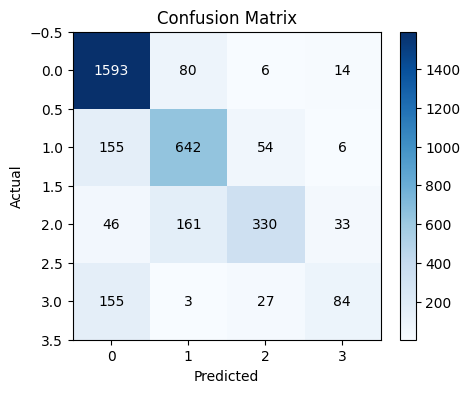

In [13]:
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Plot the Confusion Matrix
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()

# Add numbers in the boxes
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                 color='black' if cm[i, j] < cm.max()/2 else 'white')

plt.show()

The model performs well for low and moderate visual impairment risk but shows reduced recall for very high risk, with most errors occurring between adjacent risk levels, reflecting the ordinal nature and class imbalance of the data.

In [14]:
from sklearn.utils.class_weight import compute_class_weight

# y_train = your Risk_Level labels
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))
class_weight_dict


{np.int64(0): np.float64(0.5005064573309699),
 np.int64(1): np.float64(0.988744372186093),
 np.int64(2): np.float64(1.4860902255639097),
 np.int64(3): np.float64(3.147292993630573)}

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight=class_weight_dict,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)

RandomForestClassifier(class_weight={np.int64(0): np.float64(0.5005064573309699),
                                     np.int64(1): np.float64(0.988744372186093),
                                     np.int64(2): np.float64(1.4860902255639097),
                                     np.int64(3): np.float64(3.147292993630573)},
                       n_estimators=300, n_jobs=-1, random_state=42)

In [16]:
y_pred = rf_clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.78      0.80      1693
           1       0.71      0.68      0.70       857
           2       0.63      0.65      0.64       570
           3       0.22      0.30      0.26       269

    accuracy                           0.70      3389
   macro avg       0.60      0.60      0.60      3389
weighted avg       0.71      0.70      0.70      3389



Given the strong overlap and class imbalance between high and very high visual impairment risk, these categories were merged into a single high-risk class. This improved model stability, increased severe-risk recall, and produced a more clinically meaningful risk stratification for population-level screening.

In [38]:
# Merge High (2) and Very High (3) into a single High-risk class (2)
df["Risk_Level_Merged"] = df["Risk_Level"].replace({3: 2})

In [39]:
print(df["Risk_Level_Merged"].value_counts().sort_index())

Risk_Level_Merged
0    5642
1    2856
2    2797
Name: count, dtype: int64


In [40]:
feature_cols = [c for c in df.columns if c not in ["Data_Value", "Risk_Level", "Age", "Risk_Level_Merged"]]

X = df[feature_cols]
y = df["Risk_Level_Merged"]

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [42]:
rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [43]:
y_pred = rf_clf.predict(X_test)

print("Training Accuracy:", rf_clf.score(X_train, y_train))
print("Test Accuracy:", rf_clf.score(X_test, y_test))

print("\nClassification Report (Merged Classes):")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Training Accuracy: 0.8864541832669323
Test Accuracy: 0.7972554227534308

Classification Report (Merged Classes):
              precision    recall  f1-score   support

           0       0.83      0.94      0.88      1129
           1       0.72      0.72      0.72       571
           2       0.80      0.58      0.67       559

    accuracy                           0.80      2259
   macro avg       0.78      0.75      0.76      2259
weighted avg       0.79      0.80      0.79      2259


Confusion Matrix:
[[1066   49   14]
 [  90  413   68]
 [ 125  112  322]]


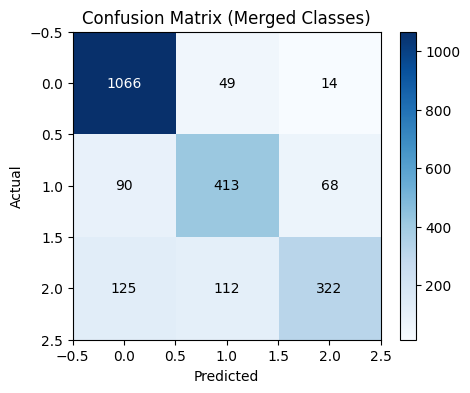

In [45]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix (Merged Classes)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()

# Add numbers in the boxes
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha='center',
            va='center',
            color='black' if cm[i, j] < cm.max()/2 else 'white'
        )

plt.show()

Merging severe risk classes reduced instability and produced a more reliable and interpretable risk stratification.

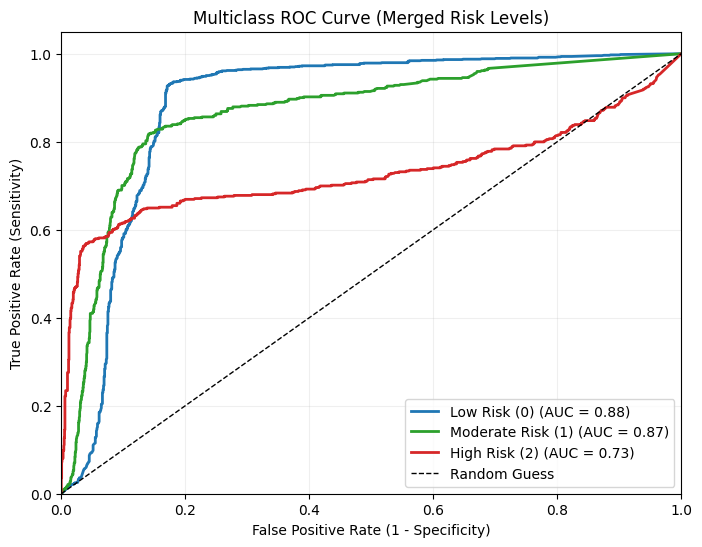

In [46]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the labels for your 3 classes (0, 1, 2)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3

# Get predicted probabilities (Crucial for ROC)
y_score = rf_clf.predict_proba(X_test)

# Plotting Setup
plt.figure(figsize=(8, 6))
colors = ['#1f77b4', '#2ca02c', '#d62728'] # Blue, Green, Red
labels = ['Low Risk (0)', 'Moderate Risk (1)', 'High Risk (2)']

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'{labels[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Multiclass ROC Curve (Merged Risk Levels)')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

## KFold Cross Validation

In [ ]:
print("Target distribution:", y.value_counts())
print("Number of samples:", len(y))
print("Feature shape:", X.shape)

Target distribution: Risk_Level
0    5642
1    2856
2    1900
3     897
Name: count, dtype: int64
Number of samples: 11295
Feature shape: (11295, 7)


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_clf, X, y, cv=5, scoring='accuracy')
print(f"CV Accuracy: {scores.mean():.4f}")

CV Accuracy: 0.6978


## Save the model

In [47]:
import joblib

# Save model
joblib.dump(rf_clf, "rf_eye_disease_model.joblib")

# Save feature columns (VERY important)
joblib.dump(feature_cols, "rf_feature_columns.joblib")

print("Model and feature columns saved.")

Model and feature columns saved.


## Load The Model


In [ ]:
import joblib
import pandas as pd

# Load
rf_clf = joblib.load("rf_eye_disease_model.joblib")
feature_cols = joblib.load("rf_feature_columns.joblib")

# Example inference
X_new = df[feature_cols]
preds = rf_clf.predict(X_new)

## Lime Explanables

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=5da9ab48209bb156cfe6defc7ec8db091b3f2e73c1880b4a21de7b8a265a3816
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
from lime.lime_tabular import LimeTabularExplainer

# Build explainer using training data
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_cols,
    class_names=["Low risk", "Moderate risk", "High risk", "Very high risk"],
    mode="classification",
    discretize_continuous=True
)


In [ ]:
exp = explainer.explain_instance(
    data_row=X_input.iloc[0].values,
    predict_fn=rf_clf.predict_proba,
    num_features=8
)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
print("\nWHY THIS RISK LEVEL WAS PREDICTED (LIME)\n")
for feature, weight in exp.as_list():
    direction = "increases" if weight > 0 else "decreases"
    print(f"- {feature} {direction} risk (weight={weight:.3f})")



WHY THIS RISK LEVEL WAS PREDICTED (LIME)

- Question <= 5.00 decreases risk (weight=-0.162)
- Age_range <= 2.00 decreases risk (weight=-0.077)
- 4.00 < RiskFactorResponseID <= 5.00 decreases risk (weight=-0.024)
- YearStart > 2016.00 decreases risk (weight=-0.021)
- 2.00 < RiskFactorID <= 3.00 decreases risk (weight=-0.014)
- Sex <= 0.00 decreases risk (weight=-0.013)
- RaceEthnicity <= 1.00 increases risk (weight=0.002)


### Interpretation

* Interpretation:
Lower predicted risk is driven mainly by a less severe eye condition, younger age group (≤40–64), and absence of strong systemic risk factors (e.g., diabetes or hypertension).

* Higher risk would be driven by older age (65+), more severe conditions (e.g., glaucoma, macular degeneration, blindness), presence of diabetes or hypertension, and questions indicating functional vision difficulty.

## Using the Model

In [ ]:
ETHNICITY_LABELS = [
    "All races",
    "Asian",
    "Black, non-Hispanic",
    "Hispanic, any race",
    "North American Native",
    "Other",
    "White, non-Hispanic"
]

In [ ]:
QUESTION_PROMPTS = [
    "Have you ever been told by a doctor that you have cataracts?",
    "Have you ever been told by a doctor that you have diabetic retinopathy?",
    "Have you ever been told by a doctor that you have glaucoma?",
    "Have you ever been told by a doctor that you have macular degeneration?",
    "Have you ever had cataract surgery?",
    "Are you blind or unable to see at all?",
    "Do you currently wear eyeglasses or contact lenses?",
    "Do you find it difficult to drive during the daytime in familiar places, even when wearing glasses or contact lenses?",
    "Do you find it difficult to notice objects off to the side, even when wearing glasses or contact lenses?",
    "Do you have trouble seeing even when wearing glasses or contact lenses?",
    "In the past 12 months, have you seen or talked to an eye care professional (optometrist, optician, or eye doctor)?",
    "Do you participate in sports or hobbies outside of work that could cause eye injury?",
    "When participating in activities that may cause eye injury, do you wear eye protection?",
    "Does the child participate in sports or hobbies that could cause eye injury?",
    "When participating in sports or hobbies that could cause eye injury, does the child wear eye protection?",
    "Does the child have trouble seeing even when wearing glasses or contact lenses?",
    "Is the child blind or unable to see at all?",
    "Does the child wear eyeglasses or contact lenses?",
    "Do you wear glasses?"
]


In [ ]:
print("\n=== VISUAL IMPAIRMENT RISK ASSESSMENT ===\n")

# -------- Year --------
year = int(input("Enter year (e.g. 2016): "))

# -------- Sex --------
print("\nSex:")
print("0 = Male | 1 = Female | 2 = Both sexes")
sex = int(input("Enter value: "))

# -------- Ethnicity --------
print("\nRace / Ethnicity:")
for i, name in enumerate(ETHNICITY_LABELS):
    print(f"{i} → {name}")

race = int(input("Choose race number: "))

# -------- Eye condition --------
print("\nVision / Eye Health Questions:")
for i, q in enumerate(QUESTION_PROMPTS):
    print(f"{i} → {q}")

question = int(input("Choose the number that best applies to you: "))

# -------- Smoking --------
print("\nSmoking status (RiskFactorResponseID):")
print("4 = No | 5 = Yes | 6 = Never")
smoking = int(input("Enter value: "))

# -------- Age --------
print("\nAge range (Age_range):")
print("0=0-17 | 1=18-39 | 2=40-64 | 3=65-84 | 4=85+ | 5=18+ | 6=All")
age_range = int(input("Enter value: "))

# BUILD INPUT ROW

row = {
    "YearStart": year,
    "Sex": sex,
    "RaceEthnicity": race,
    "Question": question,
    "Data_Value": 0.0,
    "RiskFactorID": 3,                 # RFSM
    "RiskFactorResponseID": smoking,
    "Age_range": age_range
}

X_input = pd.DataFrame([row])
X_input = X_input.reindex(columns=feature_cols, fill_value=0)

# PREDICTION
pred = rf_clf.predict(X_input)[0]
probs = rf_clf.predict_proba(X_input)[0]

risk_map = {
    0: "Low risk",
    1: "Moderate risk",
    2: "High risk",
    3: "Very high risk"
}

print("\n===== RESULT =====")
print(f"Predicted visual impairment risk level: {risk_map[pred]}")
print("Class probabilities:", np.round(probs, 3))



=== VISUAL IMPAIRMENT RISK ASSESSMENT ===

Enter year (e.g. 2016): 2020

Sex:
0 = Male | 1 = Female | 2 = Both sexes
Enter value: 0

Race / Ethnicity:
0 → All races
1 → Asian
2 → Black, non-Hispanic
3 → Hispanic, any race
4 → North American Native
5 → Other
6 → White, non-Hispanic
Choose race number: 1

Vision / Eye Health Questions:
0 → Have you ever been told by a doctor that you have cataracts?
1 → Have you ever been told by a doctor that you have diabetic retinopathy?
2 → Have you ever been told by a doctor that you have glaucoma?
3 → Have you ever been told by a doctor that you have macular degeneration?
4 → Have you ever had cataract surgery?
5 → Are you blind or unable to see at all?
6 → Do you currently wear eyeglasses or contact lenses?
7 → Do you find it difficult to drive during the daytime in familiar places, even when wearing glasses or contact lenses?
8 → Do you find it difficult to notice objects off to the side, even when wearing glasses or contact lenses?
9 → Do you h